### Loading libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
## Load the data
# load the dataset
df =pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/SDG_15_Life_on_Land_Dataset.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          1000 non-null   int64  
 1   WaterQualityIndex             1000 non-null   int64  
 2   ClimateChangeImpactScore      1000 non-null   float64
 3   LandUseChange                 1000 non-null   float64
 4   InvasiveSpeciesCount          1000 non-null   int64  
 5   ConservationFunding           1000 non-null   int64  
 6   EcoTourismImpact              1000 non-null   float64
 7   ForestCoverChange             1000 non-null   float64
 8   SoilQualityIndex              1000 non-null   int64  
 9   WaterUsage                    1000 non-null   int64  
 10  RenewableEnergyUsage          1000 non-null   int64  
 11  CarbonEmissionLevels          1000 non-null   int64  
 12  AgriculturalIntensity         1000 non-null   float64
 13  Habi

### PROBLEM STATEMENT

- This project aims to predict BiodiversityHealthIndex using environmental, ecological, and conservation-related variables. Since the target variable is continuous, the task is framed as a supervised regression problem. The objective is not only to build accurate predictive models, but also to understand which environmental factors are most strongly associated with biodiversity health.

#### Task 1.

- Definining predictors and target variables

In [3]:
X = df.drop(columns=['BiodiversityHealthIndex', 'Year'])
y = df['BiodiversityHealthIndex']


print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())
print("\nTarget column:")
print(y.name)

Feature matrix shape: (1000, 15)
Target shape: (1000,)

Feature columns:
['WaterQualityIndex', 'ClimateChangeImpactScore', 'LandUseChange', 'InvasiveSpeciesCount', 'ConservationFunding', 'EcoTourismImpact', 'ForestCoverChange', 'SoilQualityIndex', 'WaterUsage', 'RenewableEnergyUsage', 'CarbonEmissionLevels', 'AgriculturalIntensity', 'HabitatConnectivity', 'SpeciesReintroductionEfforts', 'PollinatorDiversity']

Target column:
BiodiversityHealthIndex


### NB:
- Since the target variable is a continuous data, the task is a *supervised regression*.

### Task 2.
- Performing summary statistics by exploring the data, checking assumptions to find issues before modeling

In [4]:
# Summary statistics
print(df.describe().T)

                               count         mean  ...          75%          max
Year                          1000.0  2014.840000  ...  2018.000000  2020.000000
WaterQualityIndex             1000.0    49.922000  ...    75.000000   100.000000
ClimateChangeImpactScore      1000.0     4.928142  ...     7.397943     9.970782
LandUseChange                 1000.0     5.113608  ...     7.586436     9.997138
InvasiveSpeciesCount          1000.0    25.018000  ...    38.000000    50.000000
ConservationFunding           1000.0    49.741000  ...    76.000000   100.000000
EcoTourismImpact              1000.0     4.940977  ...     7.423117     9.987929
ForestCoverChange             1000.0    -0.019767  ...     2.538136     4.994607
SoilQualityIndex              1000.0    50.089000  ...    75.000000   100.000000
WaterUsage                    1000.0    51.456000  ...    76.000000   100.000000
RenewableEnergyUsage          1000.0    50.913000  ...    77.250000   100.000000
CarbonEmissionLevels        

### Inspect the variables using visuals

##### Ploting the target variable

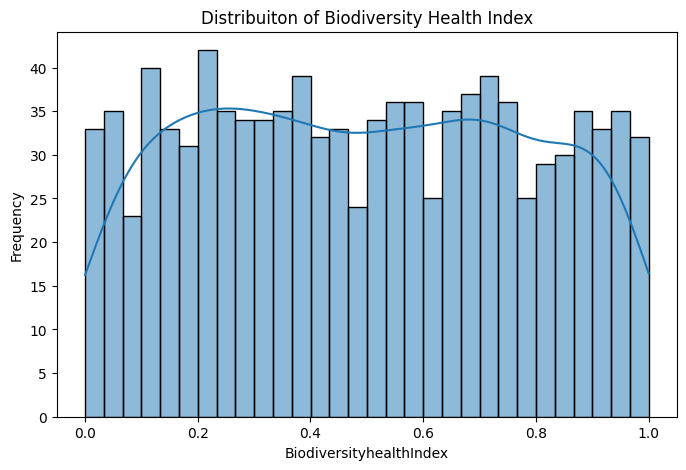

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 5))
sns.histplot(df['BiodiversityHealthIndex'], kde=True, bins=30)
plt.title('Distribuiton of Biodiversity Health Index')
plt.xlabel('BiodiversityhealthIndex')
plt.ylabel('Frequency')
plt.show()

#### Observations
- Initial exploration showed that the dataset contains 16 numeric predictors and one continuous target variable. Summary statistics and feature distribution plots revealed that the target variable, BiodiversityHealthIndex, is well distributed across its range, suggesting sufficient variability for a regression task. The distribution does not appear severely skewed, which supports proceeding with standard regression models without an immediate need for target transformation.

#### Ploting Boxplot of the Target variable

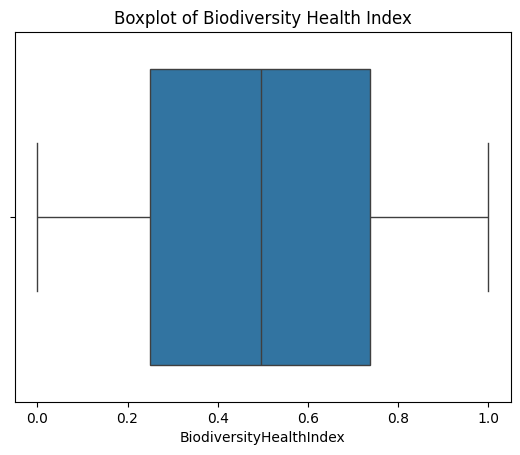

In [6]:
plt.Figure(figsize=(8,3))
sns.boxplot(x=df['BiodiversityHealthIndex'])
plt.title('Boxplot of Biodiversity Health Index')
plt.xlabel('BiodiversityHealthIndex')
plt.show()

#### Note Observations


- The boxplot of BiodiversityHealthIndex shows no major outliers and a fairly balanced spread around the median, indicating that the response variable is reasonably stable for regression modeling.









#### Inspecting the Predictor variables
- Plot Histograms of all features

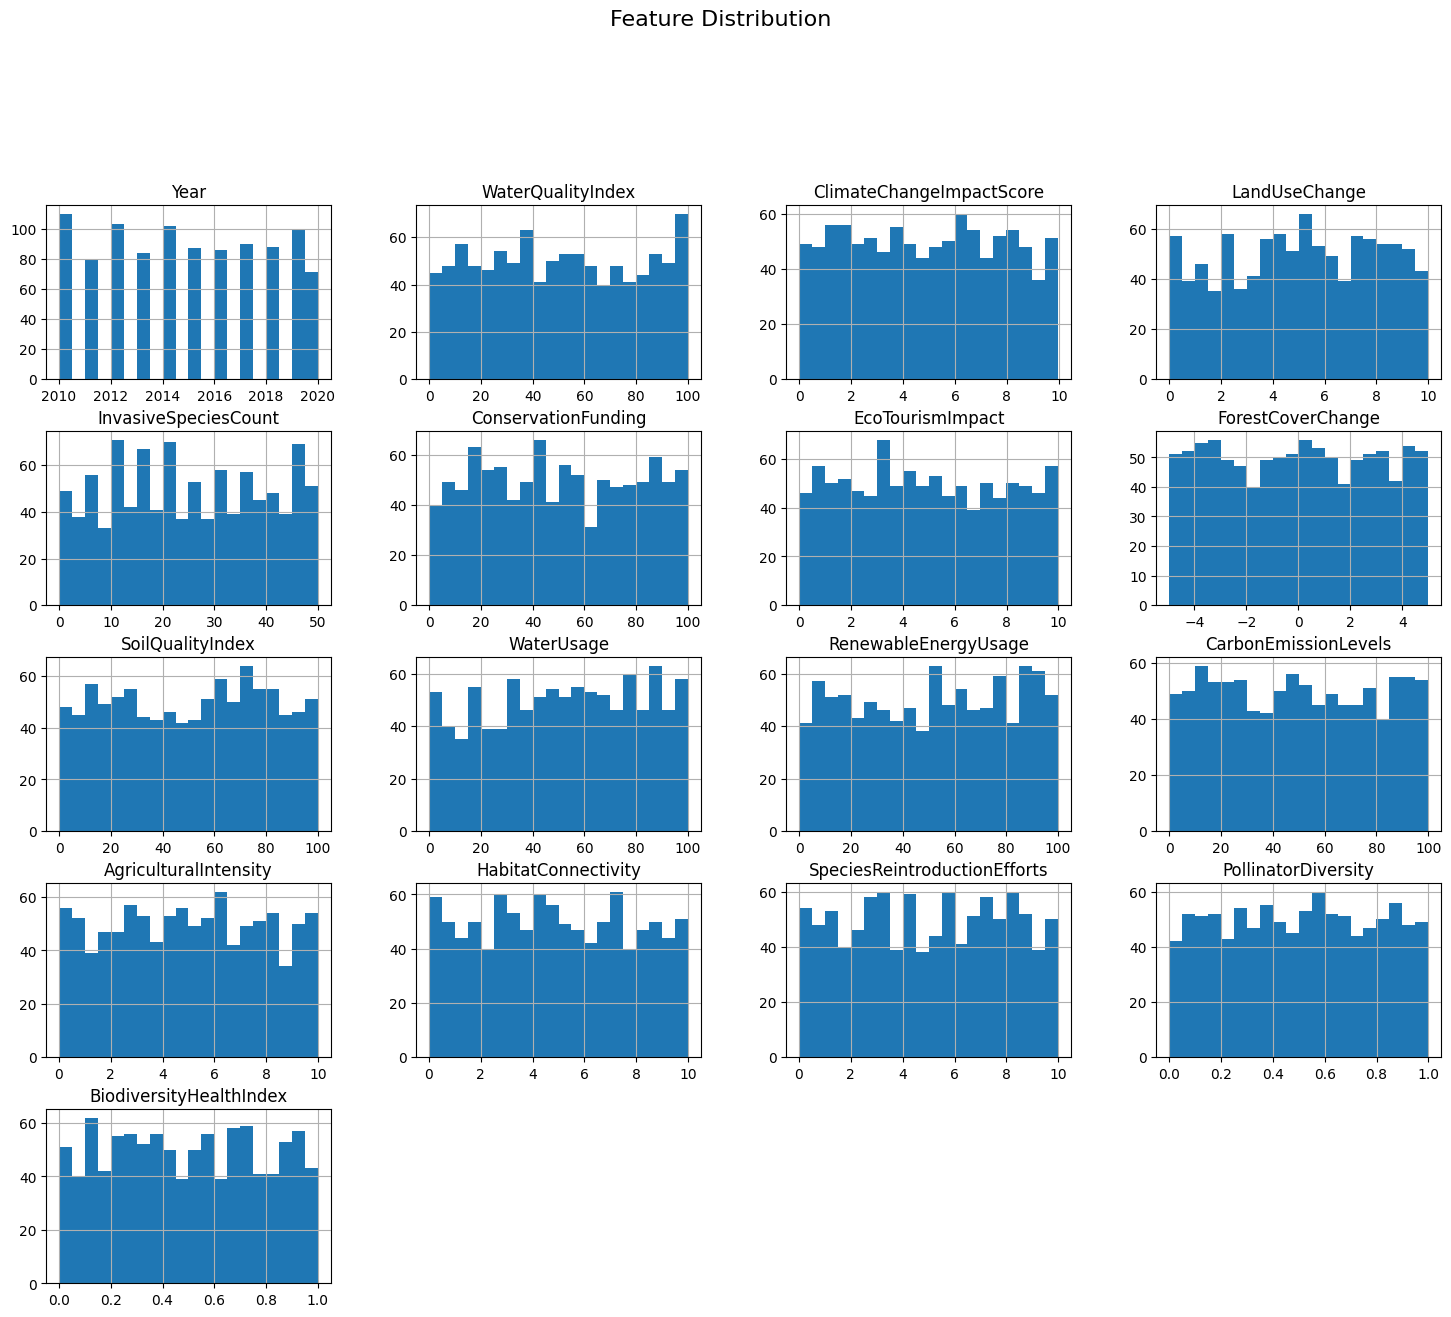

In [7]:
df.hist(figsize=(18, 14), bins=20)
plt.suptitle('Feature Distribution', y=1.02, fontsize=16)
plt.show()

#### Note Observations


- Exploratory visual analysis showed that BiodiversityHealthIndex is distributed broadly across the range 0 to 1, with no strong skewness and no severe outliers. The predictor variables also appear reasonably well distributed, although they operate on noticeably different numeric scales. This is an important finding because scale-sensitive models such as Ridge and LASSO regression require standardized input features to ensure coefficients are penalized fairly.

### Finding Features Relates most to BiodiversityHealthIndex

In [8]:
# Compute correlation matrix

corr_matrix = df.corr()

corr_matrix_df = pd.DataFrame(corr_matrix, columns=df.columns)
print(corr_matrix_df)

                                  Year  ...  BiodiversityHealthIndex
Year                          1.000000  ...                -0.026502
WaterQualityIndex            -0.029107  ...                 0.023446
ClimateChangeImpactScore     -0.027589  ...                -0.014917
LandUseChange                -0.019049  ...                 0.040171
InvasiveSpeciesCount          0.019084  ...                 0.031199
ConservationFunding          -0.029507  ...                -0.042731
EcoTourismImpact              0.015430  ...                -0.066228
ForestCoverChange            -0.031811  ...                -0.046136
SoilQualityIndex             -0.008590  ...                 0.023898
WaterUsage                    0.019444  ...                 0.007323
RenewableEnergyUsage         -0.013352  ...                -0.010840
CarbonEmissionLevels         -0.019937  ...                -0.034371
AgriculturalIntensity        -0.076085  ...                 0.023563
HabitatConnectivity           0.02

#### Ploting correlation heatmap to check correlation strength

- Predictor variables correlation

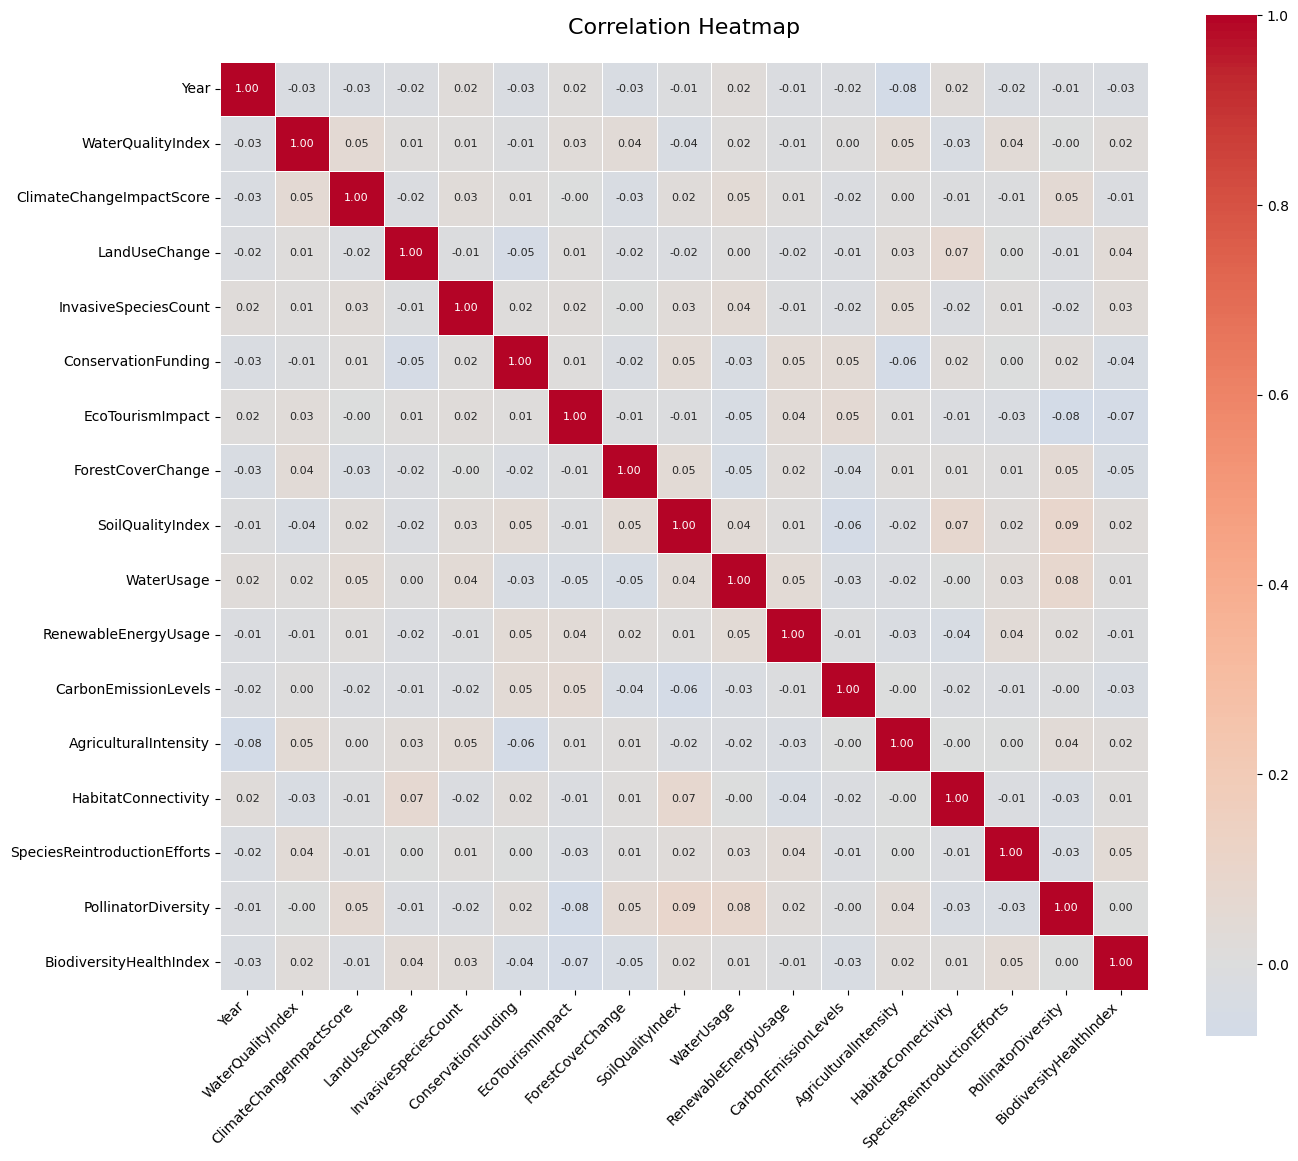

In [9]:
plt.figure(figsize=(14, 12))  # Slightly smaller but balanced dimensions
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    annot_kws={"size": 8},   # Smaller annotation text
    linewidths=0.5,          # Add grid lines for clarity
    square=True              # Keep cells square for better readability
)
plt.title('Correlation Heatmap', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.yticks(rotation=0)               # Keep y-axis labels horizontal
plt.tight_layout()                   # Prevent overlap with figure edges
plt.show()

- Target Variable correlation

In [10]:
target_corr = corr_matrix['BiodiversityHealthIndex'].sort_values(ascending=False)
print(target_corr)


BiodiversityHealthIndex         1.000000
SpeciesReintroductionEfforts    0.047989
LandUseChange                   0.040171
InvasiveSpeciesCount            0.031199
SoilQualityIndex                0.023898
AgriculturalIntensity           0.023563
WaterQualityIndex               0.023446
HabitatConnectivity             0.008568
WaterUsage                      0.007323
PollinatorDiversity             0.002505
RenewableEnergyUsage           -0.010840
ClimateChangeImpactScore       -0.014917
Year                           -0.026502
CarbonEmissionLevels           -0.034371
ConservationFunding            -0.042731
ForestCoverChange              -0.046136
EcoTourismImpact               -0.066228
Name: BiodiversityHealthIndex, dtype: float64


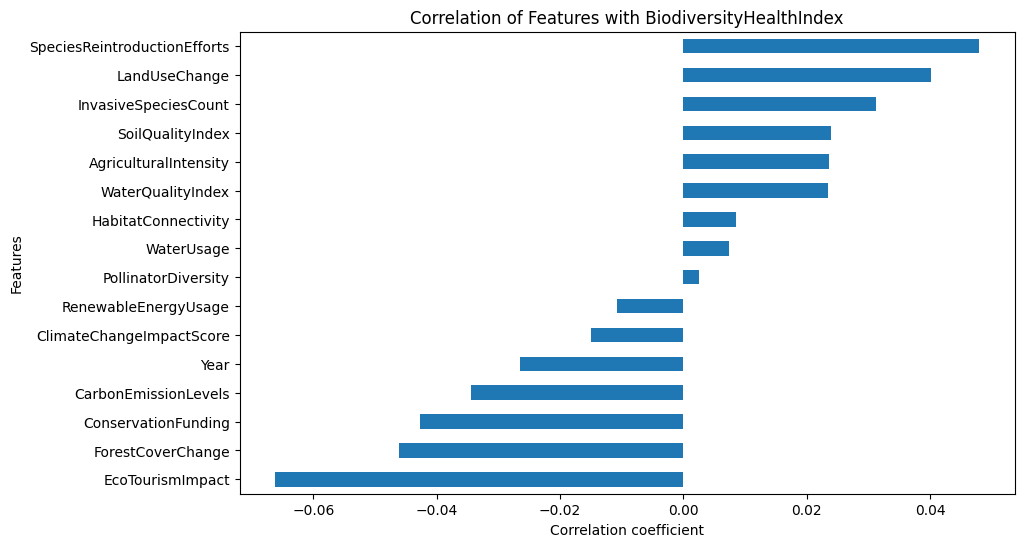

In [11]:
plt.figure(figsize=(10, 6))
target_corr.drop('BiodiversityHealthIndex').sort_values().plot(kind='barh')
plt.title('Correlation of Features with BiodiversityHealthIndex')
plt.xlabel('Correlation coefficient')
plt.ylabel('Features')
plt.show()


### 
- Top 4 correlation predictors

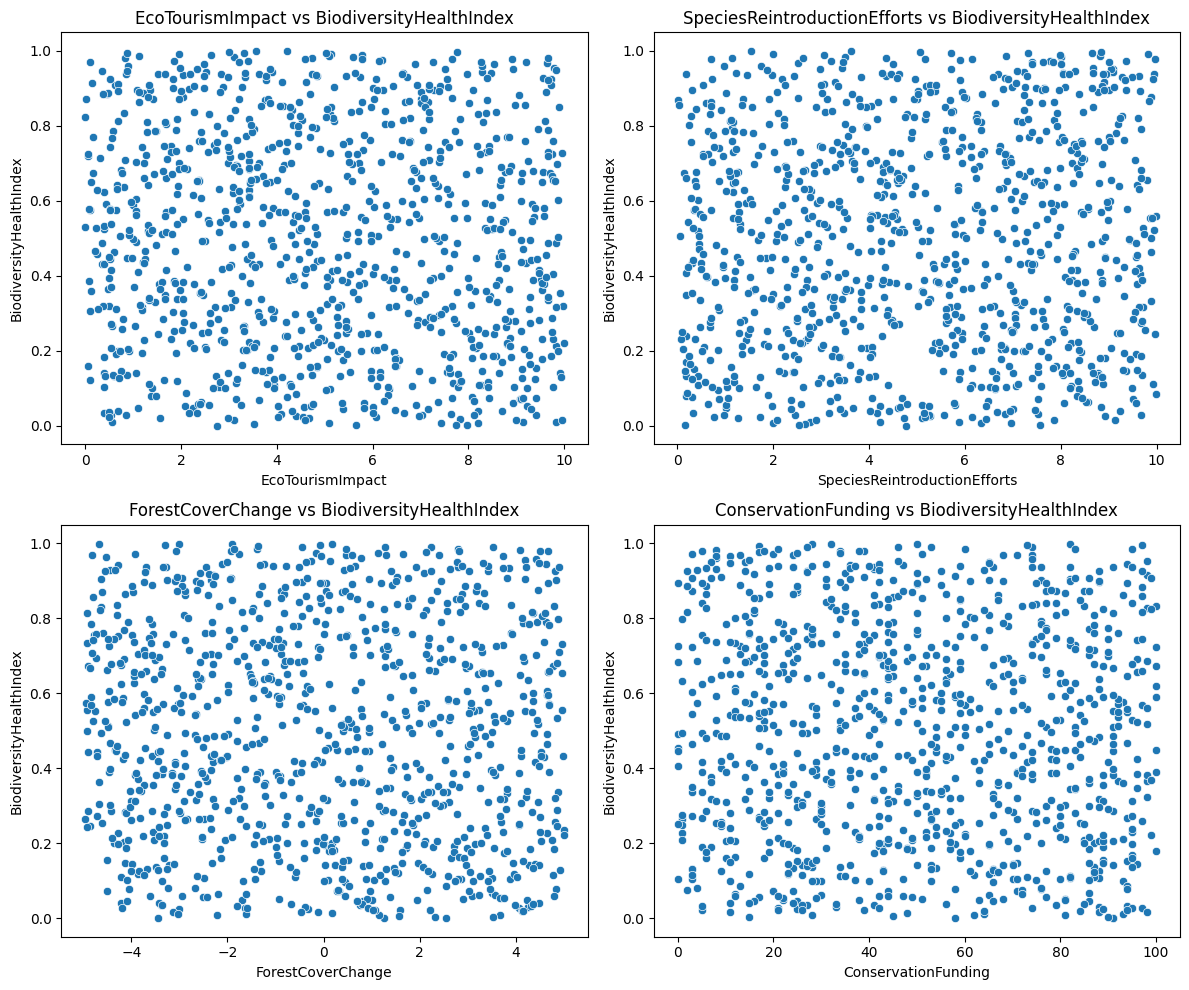

In [12]:
top_features = (
    target_corr.drop('BiodiversityHealthIndex')
    .abs()
    .sort_values(ascending=False)
    .head(4)
    .index
)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax = ax.flatten()

for i, feature in enumerate(top_features):
    sns.scatterplot(x=df[feature], y=df['BiodiversityHealthIndex'], ax=ax[i])
    ax[i].set_title(f'{feature} vs BiodiversityHealthIndex')

plt.tight_layout()
plt.show()

### Observation
- Correlation analysis revealed that the relationships between the predictors and BiodiversityHealthIndex are generally weak, with all feature-target correlations remaining close to zero. Scatterplots of the top-ranked predictors confirmed the absence of strong linear trends. In addition, the feature correlation heatmap showed little evidence of severe multicollinearity among predictors. These findings suggest that while linear and regularized regression models are still appropriate as baseline approaches, their predictive performance may be limited by weak linear signal in the data.

## Task 4

### Train-Test Split and Data Leakage Awareness

In [13]:
from sklearn.model_selection import train_test_split


# Define predictors and target featurs
X = df.drop(columns=['BiodiversityHealthIndex'])
y = df['BiodiversityHealthIndex']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 16)
X_test shape: (200, 16)
y_train shape: (800,)
y_test shape: (200,)


### Check Targeted Distribution in Train and Test

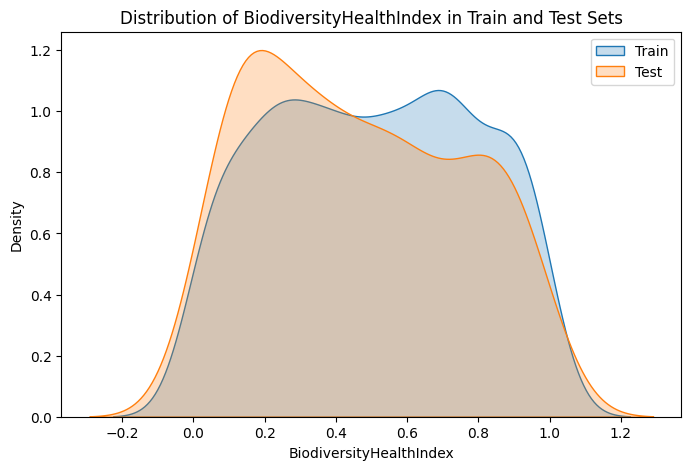

In [14]:
plt.figure(figsize=(8, 5))
sns.kdeplot(y_train, label='Train', fill=True)
sns.kdeplot(y_test, label='Test', fill=True)
plt.title('Distribution of BiodiversityHealthIndex in Train and Test Sets')
plt.xlabel('BiodiversityHealthIndex')
plt.ylabel('Density')
plt.legend()
plt.show()

#### Note
- The dataset was divided into training and test sets using an 80/20 split, resulting in 800 training observations and 200 test observations. A comparison of the target distribution across both subsets showed broadly similar shapes, suggesting that the split preserved the overall structure of the response variable and that the test set is suitable for evaluating generalization performance.

## Scaling and Training the model

In [15]:
from sklearn.preprocessing import StandardScaler


# initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier inspection
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


# Check summary
print("Scaled training feature means (approx 0):")
print(X_train_scaled_df.mean().round(2))

print("\nScaled training feature stds (approx 1):")
print(X_train_scaled_df.std().round(2))

Scaled training feature means (approx 0):
Year                            0.0
WaterQualityIndex               0.0
ClimateChangeImpactScore        0.0
LandUseChange                  -0.0
InvasiveSpeciesCount            0.0
ConservationFunding            -0.0
EcoTourismImpact                0.0
ForestCoverChange               0.0
SoilQualityIndex                0.0
WaterUsage                     -0.0
RenewableEnergyUsage            0.0
CarbonEmissionLevels           -0.0
AgriculturalIntensity           0.0
HabitatConnectivity             0.0
SpeciesReintroductionEfforts   -0.0
PollinatorDiversity            -0.0
dtype: float64

Scaled training feature stds (approx 1):
Year                            1.0
WaterQualityIndex               1.0
ClimateChangeImpactScore        1.0
LandUseChange                   1.0
InvasiveSpeciesCount            1.0
ConservationFunding             1.0
EcoTourismImpact                1.0
ForestCoverChange               1.0
SoilQualityIndex                1.0
W

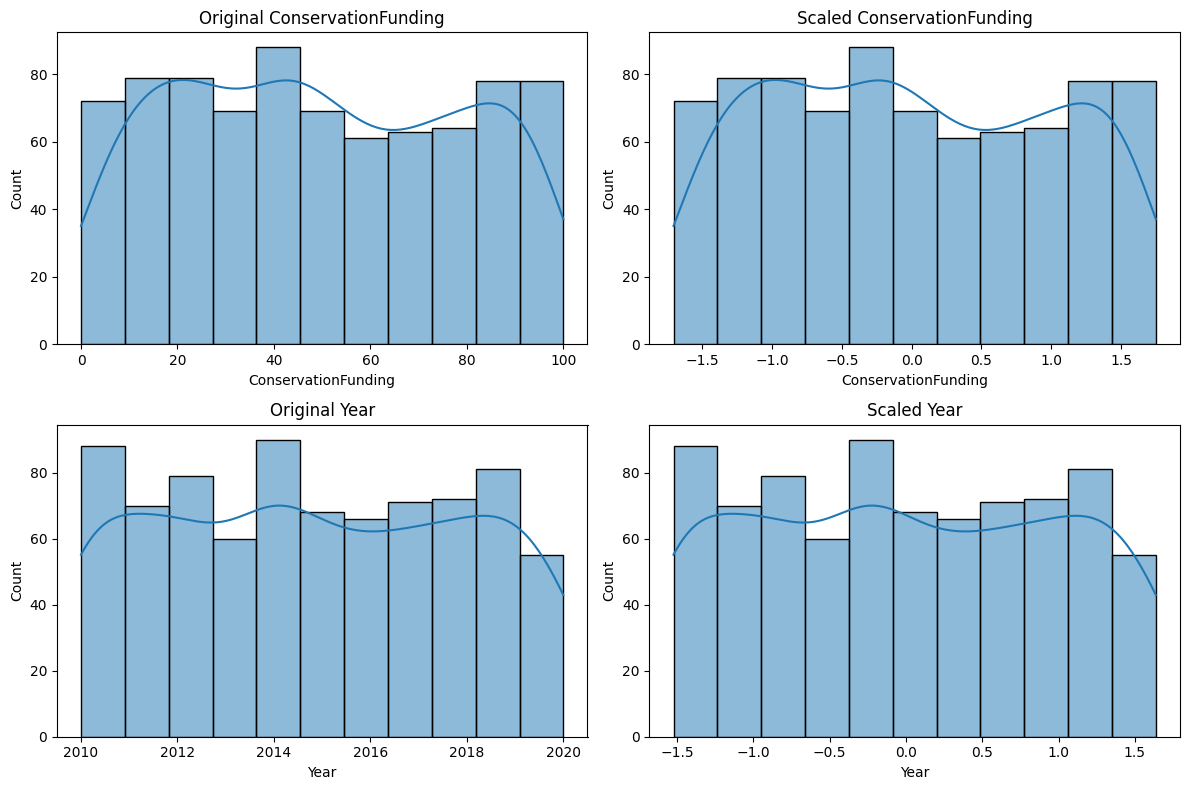

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(X_train['ConservationFunding'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Original ConservationFunding')

sns.histplot(X_train_scaled_df['ConservationFunding'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Scaled ConservationFunding')

sns.histplot(X_train['Year'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Original Year')

sns.histplot(X_train_scaled_df['Year'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Scaled Year')

plt.tight_layout()
plt.show()


- Standardization was applied successfully, with all training features transformed to approximately zero mean and unit variance. Visual comparison of original and scaled feature distributions confirmed that scaling preserved the shape of the data while aligning variables onto a common scale. This step is particularly important for regularized regression methods such as Ridge and LASSO, which penalize coefficients based on magnitude.

## Task 6

In [18]:

import numpy as np


from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# Alpha values for Ridge
alphas = np.logspace(-3, 3, 100)

# Models
linear_model = LinearRegression()
ridge_model = RidgeCV(alphas=alphas, cv=5)
lasso_model = LassoCV(cv=5, random_state=42, max_iter=10000)

# Train models
linear_model.fit(X_train_scaled, y_train)
ridge_model.fit(X_train_scaled, y_train)
lasso_model.fit(X_train_scaled, y_train)

# Predictions
linear_pred = linear_model.predict(X_test_scaled)
ridge_pred = ridge_model.predict(X_test_scaled)
lasso_pred = lasso_model.predict(X_test_scaled)


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'R2': [
        r2_score(y_test, linear_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ],
    'MAE': [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred)
    ],
    'Best Alpha': [
        np.nan,
        ridge_model.alpha_,
        lasso_model.alpha_
    ]
})

print(results)



,Model,R2,RMSE,MAE,Best Alpha
0,Linear Regression,-0.059860,0.295886,0.257522,NaN
1,Ridge Regression,-0.029789,0.291658,0.255124,1000.000000
2,Lasso Regression,-0.020437,0.290331,0.253755,0.023624


### Insights and Conclusion

The model comparison shows that all three regression models performed poorly on the test data. Although Lasso Regression produced the best result among the three models, its performance was still weak, with a negative R-squared value. This means that even the best model performed worse than simply predicting the mean value of the target variable for every observation.

Linear Regression had the lowest performance, which suggests that the relationship between the predictors and `BiodiversityHealthIndex` is not strongly linear. Ridge Regression performed slightly better than Linear Regression, indicating that regularisation helped reduce overfitting to some extent. Lasso Regression achieved the highest test performance, but it reduced all coefficients to zero, meaning that the model found very little useful predictive signal in the available features.

Overall, these results suggest that the current feature set does not explain much of the variation in `BiodiversityHealthIndex`. The weak performance is consistent with the earlier correlation analysis, which showed only weak relationships between the predictors and the target variable. To improve performance, the next step would be to engineer more informative features, check data quality, and explore more flexible non-linear models.
